# 05. Rating Curve Analysis

## What You'll Learn
In this notebook you will learn:
- Parameter estimation using MLE
- Parameter estimation using Bayesian MCMC
- Generating rating tables
- Generating uncertainty bands
- Checking model fit

## Set Up

In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import math 

from helper_functions import resolve_bestfit_dll, resolve_numerics_dll, convert_to_dotnet_array

clr.AddReference(str(resolve_numerics_dll()))
clr.AddReference(str(resolve_bestfit_dll()))

from scipy.optimize import minimize

from RMC.BestFit.Models import RatingCurve
from RMC.BestFit.Estimation import MaximumLikelihood, OptimizationMethod
from RMC.BestFit.Analyses import RatingCurveAnalysis

from Numerics.Data import TimeSeries, TimeInterval
from Numerics.Data.Statistics import Correlation, Statistics
from Numerics.Distributions import Normal

from System import DateTime, Double
from System.Collections.Generic import List

A rating curve describes the relationship between river stage (water level) and discharge (flow rate) at a gauging station. This relationship is fundamental to hydrology — while continuous water level measurements are relatively easy to obtain using pressure transducers or float gauges, direct discharge measurements are expensive, time-consuming, and can only be made periodically. The rating curve bridges this gap, allowing hydrologists to convert years of continuous stage records into flow records for flood frequency analysis, water resources planning, and real-time flood forecasting.

## Why Rating Curves Matter
Consider a typical USGS stream gauging station. A technician might visit the site 10-20 times per year to make direct discharge measurements using an acoustic Doppler current profiler (ADCP) or traditional current meter. Meanwhile, a pressure transducer records water level every 15 minutes — that's 35,000 stage readings per year, but only 10-20 paired with measured discharge.

The rating curve transforms those sparse discharge measurements into a continuous flow record. The quality of flood frequency analysis, water supply forecasting, and dam safety assessments depends critically on the accuracy of this transformation — and on honest uncertainty quantification about what we don't know.

## The Hydraulics of Open-Channel Flow

At a stable river cross-section, the relationship between water depth and flow rate is governed by fundamental hydraulic principles. For uniform, steady flow in an open channel, the Manning equation describes the relationship:

```math
Q = \frac{1}{n} \cdot A \cdot R^{2/3} \cdot S^{1/2}
```

where:
- $Q$ is discharge (volume per unit time, e.g., cubic feet per second or cubic meters per second)
- $n$ is Manning's roughness coefficient (dimensionless, typically 0.02-0.15 for natural channels)
- $A$ is the cross-sectional area of flow (perpendicular to flow direction)
- $R$ is the hydraulic radius (area divided by wetted perimeter)
- $S$ is the energy gradient (approximately equal to bed slope for uniform flow)

For a channel with a fixed cross-sectional shape, both the flow area $A$ and hydraulic radius $R$ are functions of the water depth $d$. If we measure water level relative to some datum — the stage $h$ — then we can write:

```math
A = f_1(h - \xi)
```
```math
R = f_2(h - \xi)
```

where $\xi$ is the stage at which discharge equals zero (the "zero-flow stage" or "point of zero flow"). The functions $f_1$ and $f_2$ depend on channel geometry.

For many natural channels, these geometric relationships can be approximated by power functions, leading to the classic power-law rating curve:

```math
Q = \alpha \cdot (h - \xi)^{\beta}
```

This deceptively simple equation captures the essential physics: discharge increases as a power of the effective depth $(h - \xi)$, with the coefficient $\alpha$ encoding channel properties (roughness, slope, width) and the exponent $\beta$ reflecting how the flow area and hydraulic radius change with depth.

### Understanding the Parameters

Each parameter in the rating curve equation has physical meaning that helps guide model fitting and interpretation:

**Main-channel Zero-Flow Stage ($h_1$)**: The stage reading at which the main-channel power law evaluates to zero — essentially the elevation of the lowest point of the main hydraulic control relative to the gauge datum. ISO 1100-2:2010 §5.2.5 refers to this as the **effective gauge height of zero flow**. For a gauge with its zero set at the low-flow control (riffle or weir) thalweg, $h_1 \approx 0$; for gauges referenced to an arbitrary datum (common with pressure transducers) $h_1$ might be several feet.

**Activation Stages ($h_2, h_3$)**: Under BaRatin addition mode, each additional control (overbank floodplain, secondary terrace, etc.) activates at a threshold stage $h_k$ and contributes $\alpha_k (h - h_k)^{\beta_k}$ on top of the already-active controls. The activation stage plays the dual role of *threshold* and *offset*. The same naming convention is used for all controls ($h_1, h_2, h_3$) — the main-channel zero-flow stage is simply the "b" offset of control 1.

**Coefficient ($\alpha$)**: This parameter combines the effects of channel roughness, bed slope, and cross-sectional geometry. Larger values indicate a more hydraulically efficient channel — smooth banks, steep gradient, or wide cross-section. The units of $\alpha$ depend on the units of $h$ and $Q$, making physical interpretation of its magnitude difficult without knowing the unit system.

**Exponent ($\beta$)**: The exponent reflects how rapidly the conveyance capacity increases with stage. For a wide rectangular channel where width dominates, $\beta \approx 5/3 \approx 1.67$. For a channel where increasing stage primarily increases depth (narrow, steep banks), $\beta$ can exceed 2.5. Typical values for natural channels:

| Channel Type | Typical $\beta$ | Physical Interpretation |
|--------------|-----------------|------------------------|
| Wide, shallow floodplain | 1.3 - 1.5 | Small depth increase → large area increase |
| Typical natural channel | 1.5 - 2.0 | Balanced depth and width response |
| Deep, narrow channel | 2.0 - 2.5 | Depth dominates width |
| Steep mountain stream | 2.5 - 3.0 | Confined geometry with high gradient |

### Why Channels Change Behavior

Real rivers don't maintain the same geometry across all flow conditions. A typical river has distinct zones:

1. Low flow: Water is confined to the main channel thalweg. The wetted perimeter is relatively large compared to flow area, creating high friction losses.
2. Bankfull flow: The main channel is full but flow hasn't spilled onto the floodplain. This is often the most hydraulically efficient condition.
3. Overbank flow: Water has spilled onto the floodplain. The flow area increases dramatically, but so does friction from vegetation and irregular terrain. The effective slope may decrease as water takes longer paths across the floodplain.

These transitions create distinct "segments" in the rating curve, each with different parameters. The ***RMC-BestFit*** library supports up to three segments to capture these physical changes.

#### Single-Segment Model

The basic rating curve model relates stage $h$ to discharge $Q$ through a power law:

```math
Q = \alpha \cdot (h - \xi)^{\beta}
```

However, discharge measurements are never perfect. Measurement uncertainty, turbulence, unsteady flow, and channel changes all introduce variability. Following standard practice in hydrology, we model this uncertainty in logarithmic space, which is equivalent to assuming multiplicative errors:

```math
\log_{10}(Q_i) = \log_{10}(\alpha) + \beta \cdot \log_{10}(h_i - \xi) + \varepsilon_i
```

where $\varepsilon_i \sim N(0, \sigma^2)$ represents measurement error in log-space.

The single-segment model has **four parameters**: $[h_1, \log_{10}(\alpha_1), \beta_1, \sigma]$.

#### Multi-Segment Model — BaRatin Addition Mode

For compound channels, the main channel continues to carry flow above bankfull while additional hydraulic controls (overbank floodplain, secondary terraces, etc.) activate and contribute on top of the main-channel flow. ***RMC-BestFit*** models this with the BaRatin matrix-of-controls framework (Le Coz et al. 2014 [[5]](#5)) in **addition mode**: each additional control activates at its own threshold stage $h_k$ and adds its own power-law contribution.

The authoritative BaRatin master equation, as implemented in the [reference Fortran engine](https://github.com/BaRatin-tools/BaRatin/blob/main/src/RatingCurve_tools.f90), is:

```math
Q(h) = \sum_{r=1}^{N_{\text{segment}}} \mathbb{1}_{[\kappa_r;\,\kappa_{r+1}]}(h) \,\cdot\, \sum_{j=1}^{N_{\text{control}}} M(r,j)\, a_j\, (h - b_j)^{c_j}
```

where $M(r, j)$ is a lower-triangular binary matrix specifying which controls are active in each stage segment, and $b_j$ is derived from BaRatin's continuity condition. Different choices of $M$ encode different physical configurations:

- **Addition mode** (each row has the 1s of the previous row plus a new 1 — e.g. 2-segment $M = \begin{pmatrix}1&0\\1&1\end{pmatrix}$): controls *accumulate*. A new control activates on top of already-active ones. Continuity collapses to $b_j = \kappa_j$. Appropriate for main-channel + overbank-floodplain (the flood-frequency use case).
- **Succession mode** (each row has exactly one 1 — e.g. 2-segment $M = I_2$): one control *replaces* another. Continuity is enforced by a root-find on $b_j$. Appropriate for drowning weirs / stage-fall-discharge sites.

***RMC-BestFit*** defaults to the addition-mode matrix $M = \begin{pmatrix}1&0&0\\1&1&0\\1&1&1\end{pmatrix}$ (for up to three controls). Succession-mode and mixed matrices are deferred to a future release.

> **Physics of compound channels.** For a main channel + wide-rectangular overbank floodplain, Manning's equation gives $Q_{main}(h) = \alpha_1 (h - h_1)^{\beta_1}$ as a continuing contribution above bankfull, and $Q_{ob}(h) = (1.49/n_{ob})\,W_{ob}\,S^{1/2}\,(h - h_{bf})^{5/3}$ as a separate Manning-derived power law in overbank depth. Total discharge is their sum. Wickert et al. (2024/2025) [[11]](#11) describe this "double-Manning" approach explicitly for rating-curve development.

#### Two-Segment Addition-Mode Model

```math
Q(h) = \alpha_1(h - h_1)^{\beta_1} + \alpha_2(h - h_2)^{\beta_2}\,\mathbb{1}\{h > h_2\}
```

Below $h_2$ only the main-channel power law is active. At $h = h_2$ the overbank term is zero, so the rating curve is continuous by construction. Above $h_2$, both controls contribute.

The two-segment model has **seven free parameters**: $[h_1, \log_{10}(\alpha_1), \beta_1, h_2, \log_{10}(\alpha_2), \beta_2, \sigma]$. Note that $h_2$ serves a dual role: it is both the *activation stage* of the second control and the *offset* $b_2$ of its power-law term (an automatic consequence of the BaRatin addition-mode continuity derivation).

#### Three-Segment Addition-Mode Model

```math
Q(h) = \alpha_1(h - h_1)^{\beta_1} + \alpha_2(h - h_2)^{\beta_2}\,\mathbb{1}\{h > h_2\} + \alpha_3(h - h_3)^{\beta_3}\,\mathbb{1}\{h > h_3\}
```

Three hydraulic controls successively activate as stage rises (e.g., main channel, then inner floodplain, then outer floodplain). Each contribution is zero at its own activation stage, so the rating curve is C⁰ continuous at both $h_2$ and $h_3$.

The three-segment model has **ten free parameters**: $[h_1, \log_{10}(\alpha_1), \beta_1, h_2, \log_{10}(\alpha_2), \beta_2, h_3, \log_{10}(\alpha_3), \beta_3, \sigma]$.

With ten parameters, the three-segment model requires substantial data — ideally 100+ observations distributed across all three stage regimes — and careful attention to convergence diagnostics.

## Stage / Discharge Alignment

The two input time series supplied to the rating curve — stage $h_i$ and discharge $Q_i$ — are **not required to match index-for-index or to have the same length**. Real-world gauge records (USGS, Water Data for the Nation) routinely return stage and discharge series whose date ranges overlap only partially. ***RMC-BestFit*** inner-joins the two series by `DateTime` index and fits the rating curve to the **common-date pairs only**:

```math
\mathcal{D} = \bigl\{ (h_i, Q_i) \;\big|\; \text{date}_i \in \text{Stage.Dates} \cap \text{Discharge.Dates} \bigr\}
```

Observations whose date appears in only one series are silently dropped from the fit and from every derived diagnostic (residuals, fitted values, RMSE, AIC / BIC / DIC, posterior-predictive plots).

## Parameter Estimation

### Maximum Likelihood Estimation

Maximum Likelihood Estimation (MLE) finds the parameter values that maximize the log-likelihood — equivalently, the parameters under which the observed data are most probable:

```math
\hat{\theta}_{\text{MLE}} = \arg\max_{\theta} \ell(\theta)
```

For rating curves, the likelihood surface can have multiple local optima and ridges, especially for multi-segment models. The `MultilevelSingleLinkage` global optimizer is recommended.


**Advantages of MLE:**
- Fast computation (typically seconds)
- Produces point estimates suitable for operational use
- Good starting point for MCMC

**Limitations of MLE:**
- No uncertainty quantification on parameters
- Can find local optima instead of global optimum
- Standard errors (when available) assume normality that may not hold

Zero-flow stage (ξ):   0.495
Log₁₀(α):              1.401
Exponent (β):          1.111
Log-space error (σ):   0.8820
Log-likelihood:        90.53


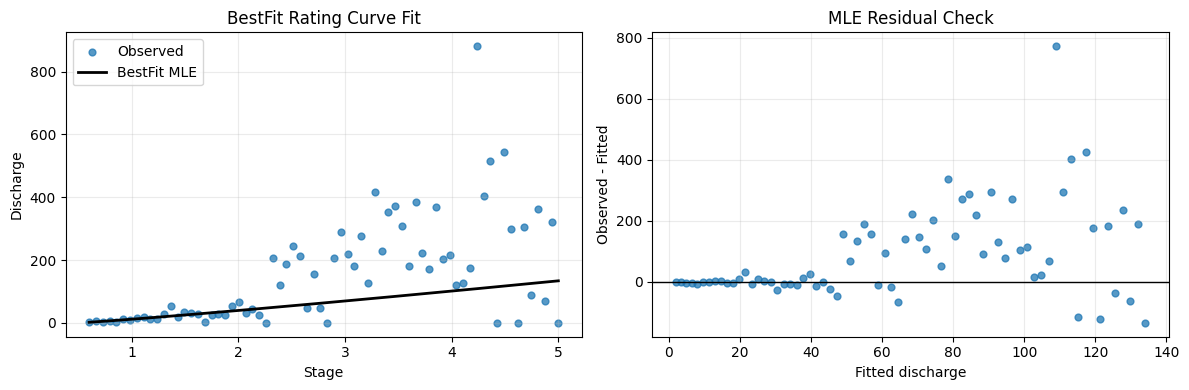

In [2]:
# Create synthetic data
stage = np.linspace(0.6, 5.0, 70)
discharge_true = np.where(stage < 2.2, 18*(stage-0.3)**1.7, 65*(stage-0.3)**1.15)
discharge_obs = np.maximum(0.1, discharge_true * (1 + np.array(Normal(0,0.8).GenerateRandomValues(len(stage), 123)) ))

stage_ts = TimeSeries(TimeInterval.OneDay, DateTime(2000,1,1), convert_to_dotnet_array(stage))
discharge_ts = TimeSeries(TimeInterval.OneDay, DateTime(2000,1,1), convert_to_dotnet_array(discharge_obs))

# Create the rating curve model
model = RatingCurve(stage_ts, discharge_ts, numberOfSegments=1)

# Fit using global optimization
mle = MaximumLikelihood(model, OptimizationMethod.MultilevelSingleLinkage)
mle.Estimate()

# Check convergence and extract parameters
if mle.IsEstimated:
    model.SetParameterValues(mle.BestParameterSet.Values)

    print(f"Zero-flow stage (ξ):   {model.Parameters[0].Value:.3f}")
    print(f"Log₁₀(α):              {model.Parameters[1].Value:.3f}")
    print(f"Exponent (β):          {model.Parameters[2].Value:.3f}")
    print(f"Log-space error (σ):   {model.Parameters[3].Value:.4f}")
    print(f"Log-likelihood:        {mle.BestParameterSet.Fitness:.2f}")

stage_grid = np.linspace(float(np.min(stage)), float(np.max(stage)), 200)
fitted_grid = [model.Predict(mle.BestParameterSet.Values, float(h)) for h in stage_grid]
fitted_obs = [model.Predict(mle.BestParameterSet.Values, float(h)) for h in stage]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(stage, discharge_obs, s=24, alpha=0.75, label="Observed")
axes[0].plot(stage_grid, fitted_grid, color="black", linewidth=2, label="BestFit MLE")
axes[0].set_xlabel("Stage")
axes[0].set_ylabel("Discharge")
axes[0].set_title("BestFit Rating Curve Fit")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].scatter(fitted_obs, np.array(discharge_obs) - np.array(fitted_obs), s=24, alpha=0.75)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("Fitted discharge")
axes[1].set_ylabel("Observed - Fitted")
axes[1].set_title("MLE Residual Check")
axes[1].grid(alpha=0.25)
plt.tight_layout()

### Bayesian MCMC Estimation

Bayesian estimation provides full uncertainty quantification by characterizing the posterior distribution of parameters given the data:

```math
\pi(\theta | \text{data}) \propto \mathcal{L}(\text{data} | \theta) \cdot \pi(\theta)
```

The ***RMC-BestFit*** library uses the **DEMCzs** sampler (Differential Evolution MCMC with snooker update) [[1]](#1), which is self-tuning and robust to multimodal posteriors.

**Advantages of Bayesian MCMC:**
- Full posterior distribution, not just point estimates
- Proper uncertainty propagation to derived quantities (e.g., the 100-year discharge)
- Incorporates prior information when available
- Provides convergence diagnostics (R-hat, ESS)

Parameter posterior summaries:
Parameter                       Mean    Std Dev   95% CI Lower   95% CI Upper    R-hat
Zero-Flow Stage (h₁)         -1.5362     1.2585        -3.5413         0.3728    1.000
Coefficient (α₁)              0.0359     0.9532        -1.6832         1.3533    1.000
Exponent (β₁)                 2.6036     1.0528         1.0444         4.4561    1.000
Scale (σ)                     0.9162     0.0797         0.7949         1.0564    1.000


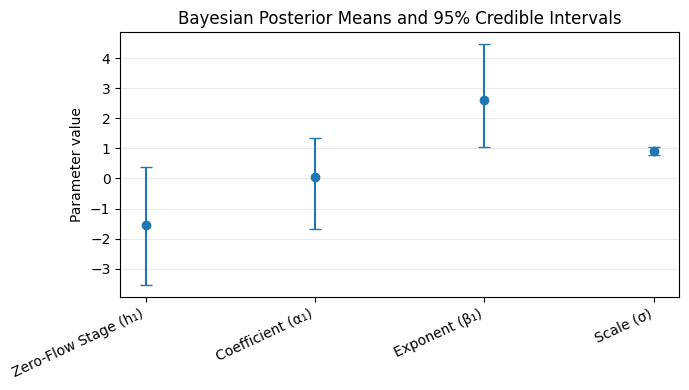

In [3]:
# Create the rating curve model (using the same data as before)
model = RatingCurve(stage_ts, discharge_ts, numberOfSegments=1)

# Configure Bayesian analysis
analysis = RatingCurveAnalysis(model)
analysis.BayesianAnalysis.Iterations = 10000
analysis.BayesianAnalysis.WarmupIterations = 5000

# Run analysis
analysis.RunAsync().Wait()

# Access posterior summaries
results = analysis.BayesianAnalysis.Results
print("Parameter posterior summaries:");
print(F"{"Parameter":<25} {"Mean":>10} {"Std Dev":>10} {"95% CI Lower":>14} {"95% CI Upper":>14} {"R-hat":>8}")

for i in  range(model.Parameters.Count):
    stats = results.ParameterResults[i].SummaryStatistics
    print(f"{model.Parameters[i].Name:<25} {stats.Mean:>10.4f} {stats.StandardDeviation:>10.4f} " +
                      f"{stats.LowerCI:>14.4f} {stats.UpperCI:14.4f} {stats.Rhat:>8.3f}")

parameter_names = [model.Parameters[i].Name for i in range(model.Parameters.Count)]
means = []
lower = []
upper = []
for i in range(model.Parameters.Count):
    stats = results.ParameterResults[i].SummaryStatistics
    means.append(float(stats.Mean))
    lower.append(float(stats.LowerCI))
    upper.append(float(stats.UpperCI))

x = np.arange(len(parameter_names))
yerr = np.array([np.array(means) - np.array(lower), np.array(upper) - np.array(means)])
plt.figure(figsize=(7, 4))
plt.errorbar(x, means, yerr=yerr, fmt="o", capsize=4)
plt.xticks(x, parameter_names, rotation=25, ha="right")
plt.ylabel("Parameter value")
plt.title("Bayesian Posterior Means and 95% Credible Intervals")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

**Considerations:**
- Slower than MLE (can take minutes instead of seconds)
- Requires checking convergence diagnostics
- Prior specification can influence results (though default flat priors are usually appropriate)

#### Prior Distributions

The ***RMC-BestFit*** library uses weakly informative default priors that place minimal constraints while ensuring computational stability:

| Parameter | Default Prior | Rationale |
|-----------|--------------|-----------|
| $h_1$ (main-channel zero-flow stage) | $\text{Uniform}(\min(h) - \text{range}(h),\ \min(h) + 0.1\cdot\text{range}(h))$ | Must be below minimum observed stage |
| $\log_{10}(\alpha_k)$ (per-control coefficients, all $k$) | $\text{Uniform}(-5, 5)$ | Covers realistic range of coefficients |
| $\beta_k$ (per-control exponents) | $\text{Uniform}(0.5, 5.0)$ | Physical constraints on channel geometry |
| $h_2$ (second-control activation stage) | $\text{Uniform}(\min(h)+0.2\cdot\text{range}(h),\ \min(h)+0.7\cdot\text{range}(h))$ | Keeps the activation stage inside the data range, well away from the extremes |
| $h_3$ (third-control activation stage) | $\text{Uniform}(\min(h)+0.5\cdot\text{range}(h),\ \max(h))$ | Sits above $h_2$ and within the data range |
| $\sigma$ (error scale) | $\text{Uniform}(\epsilon,\ 3\cdot\text{std}(\log_{10}Q))$ + optional Jeffreys | Small positive to reasonable upper bound |

Under BaRatin addition mode $h_k$ serves a dual role — it is both the *activation stage* and the *offset* of control $k$'s power-law term — because the continuity derivation collapses to $b_k = \kappa_k$ when a control persists across all upper segments. No separate $\xi_2, \xi_3$ priors are needed.

When `UseJeffreysRuleForScale = true` (the default), the error scale receives Jeffreys' prior:

```math
\pi(\sigma) \propto \frac{1}{\sigma}
```

This non-informative prior is appropriate for scale parameters and produces posteriors that are invariant to rescaling of the data.


COMEBACK: Way to compare Bayesian MCMC vs MLE??

#### Parameter Identifiability (The ξ-α-β Trade-off)

Within a single segment, the power-law rating curve parameters $\xi$, $\alpha$, and $\beta$ are not fully independent — the relation

```math
Q = \alpha \cdot (h - \xi)^{\beta}
```

can be approximately reproduced over a limited stage range by different combinations of the three parameters, creating a ridge in the likelihood surface. Shifting $\xi$ upward and compensating with changes in $\alpha$ and $\beta$ gives nearly identical discharge predictions when the dynamic range of $(h - \xi)$ is narrow.

This ridge is most pronounced when:

1. **Data doesn't extend to low flows**: Without observations near the true zero-flow stage, the data cannot constrain $\xi$.
2. **Limited stage range**: A narrow range of observed stages provides little leverage to distinguish between parameter combinations.
3. **High measurement error**: Noise masks the subtle differences between competing parameter sets.

> **Why the BaRatin addition mode helps.** The $(\xi, \beta)$ ridge is a classical weak-identification signature of power-law regression when both the location and the exponent must be fit jointly. Under the addition-mode formulation used by ***RMC-BestFit***, only the main-channel location $h_1$ is a free parameter — the activation stages $h_k$ for $k \geq 2$ serve as both activation thresholds and "offsets" of each control's power-law term, which decouples them from the main-channel regression. Below $h_2$ the data pin $(h_1, \alpha_1, \beta_1)$ via ordinary log-log regression; above $h_2$ the residual discharge is a clean power law in $(h - h_2)$ that pins $(\alpha_2, \beta_2)$ independently. The segment-1 location $h_1$ is still fit and can still suffer from weak identification when low-flow data are sparse or narrow — the guidance in this section primarily applies to $h_1$.

##### Diagnosing Identifiability Problems

Signs of identifiability issues include:

- **High posterior correlation**: Check correlation between $\xi$, $\alpha$, and $\beta$ in MCMC output
- **Wide credible intervals**: Especially on $\xi$ and $\beta$
- **Slow MCMC mixing**: Low effective sample size despite many iterations
- **Sensitivity to priors**: Results change substantially with different prior specifications

In [4]:
# Check parameter correlations after MCMC
output = analysis.BayesianAnalysis.Results.Output
xi_samples = np.zeros(len(output))
log_alpha_samples = np.zeros(len(output))
beta_samples = np.zeros(len(output))

# Extract posterior samples for correlation analysis
for i, p in enumerate(output):
    xi_samples[i] = p.Values[0]
    log_alpha_samples[i] = p.Values[1]
    beta_samples[i] = p.Values[2]

# Compute correlation (using Numerics.Data.Statistics)
xi_samples_net = convert_to_dotnet_array(xi_samples)        # Convert to .NET arrays to pass to Numerics method
beta_samples_net = convert_to_dotnet_array(beta_samples)
corr_xi_beta = Correlation.Pearson(xi_samples_net, beta_samples_net)
print(f"Correlation(ξ, β): {corr_xi_beta:.3f}")

if (np.abs(corr_xi_beta)> 0.9):
    print("Warning: High correlation between ξ and β suggests identifiability issues.")

Correlation(ξ, β): -0.707


Several strategies can improve parameter identifiability:

1. Include low-flow measurements: The most effective solution is to have discharge measurements at stages close to the true zero-flow stage.
2. Use informative priors: If the gauge datum is known from surveys, specify an informative prior on $\xi$.
3. Fix $\xi$ if known: If the zero-flow stage has been surveyed or is known from channel geometry, fix it rather than estimating.
4. Use physical constraints: Ensure the prior on $\beta$ reflects physical reality (typically 1.0-3.5 for natural channels).

In [5]:
# 1. Data with good low-flow coverage
min_observed_stage = stage.min()
true_xi = 0.5      # Known or estimated zero-flow stage
if (min_observed_stage - true_xi > 0.5):
    print("Warning: Minimum observed stage is far from zero-flow stage. ξ may be poorly identified.")

# 2. If gauge is zero at the channel thalweg, ξ should be near 0
model.Parameters[0].PriorDistribution = Normal(0.0, 0.2)

# 3. Fix zero-flow stage at surveyed value
model.Parameters[0].Value = 0.3
model.Parameters[0].IsFixed = True

## Working with Results

### Generating Rating Tables
A rating table provides stage-discharge pairs for operational use.

In [6]:
analysis = RatingCurveAnalysis(model)
analysis.RunAsync().Wait()

# Use MAP (Maximum A Posteriori) parameters for best point estimate
map_params = analysis.BayesianAnalysis.Results.MAP.Values

# Generate rating table
table = model.GenerateRatingTable(parameters=map_params,
                                    minStage=0,
                                    maxStage=15,
                                    numPoints=100)

# Export to CSV (should appear in the same folder as this notebook)
with open("rating_table.csv", mode="w") as f:
    writer = csv.writer(f)

    # Header
    writer.writerow(["Stage", "Discharge"])

    for i in range(table.GetLength(0)):
        stage_i = f"{table[i,0]:.3f}"
        discharge = f"{table[i,1]:.3f}"
        writer.writerow([stage_i, discharge])

### Uncertainty Bands on Rating Curve
To visualize uncertainty, generate predictions from multiple posterior samples.

In [7]:
posterior_samples = analysis.BayesianAnalysis.Results.Output
stages = np.array([0.5 + i*0.15 for i in range(100)])

# Store predictions for each stage and posterior sample
predictions = np.zeros((len(stages), len(posterior_samples)))

# Fill prediction matrix
for j, sample in enumerate(posterior_samples):
    params = sample.Values
    for i, stage_j in enumerate(stages):
        predictions[i,j] = model.Predict(params,stage_j)

# Compute percentiles at each stage
print("Stage    Q_median    Q_2.5%    Q_97.5%")

for i in range(len(stages)):
    row = predictions[i, :]     # All posterior draws at this stage
    row_sorted = np.sort(row)   
    median = row_sorted[len(row_sorted)//2]
    lower = Statistics.Percentile(convert_to_dotnet_array(row_sorted), 0.025, True)
    upper = Statistics.Percentile(convert_to_dotnet_array(row_sorted), 0.975, True)
    print(f"{stages[i]:.2f}     {median:.1f}       {lower:.1f}      {upper:.1f}")

# ADD GRAPH

Stage    Q_median    Q_2.5%    Q_97.5%
0.50     3.4       0.5      15.0
0.65     5.4       1.5      18.8
0.80     7.7       2.6      22.5
0.95     10.3       4.0      26.2
1.10     13.1       5.6      30.1
1.25     16.2       7.6      34.3
1.40     19.5       9.7      38.5
1.55     22.9       12.3      43.3
1.70     26.6       14.9      48.1
1.85     30.5       17.7      53.6
2.00     34.6       20.5      59.4
2.15     38.9       23.4      65.7
2.30     43.4       26.4      72.5
2.45     48.0       29.3      80.0
2.60     52.8       32.2      88.3
2.75     57.9       35.2      96.9
2.90     63.2       38.0      106.9
3.05     68.7       40.5      116.8
3.20     74.2       43.0      128.3
3.35     79.8       45.6      140.3
3.50     85.9       48.2      153.2
3.65     91.7       50.7      165.8
3.80     97.9       53.1      180.9
3.95     104.1       55.2      196.9
4.10     110.6       57.8      213.8
4.25     117.0       60.0      232.3
4.40     123.8       62.1      252.3
4.55     13

### Checking Model Fit
Examine residuals to check model adequacy.

Mean residual: -0.0074 (should be near 0)
Std deviation of residuals: 0.8863 (should be near σ = 0.8801)


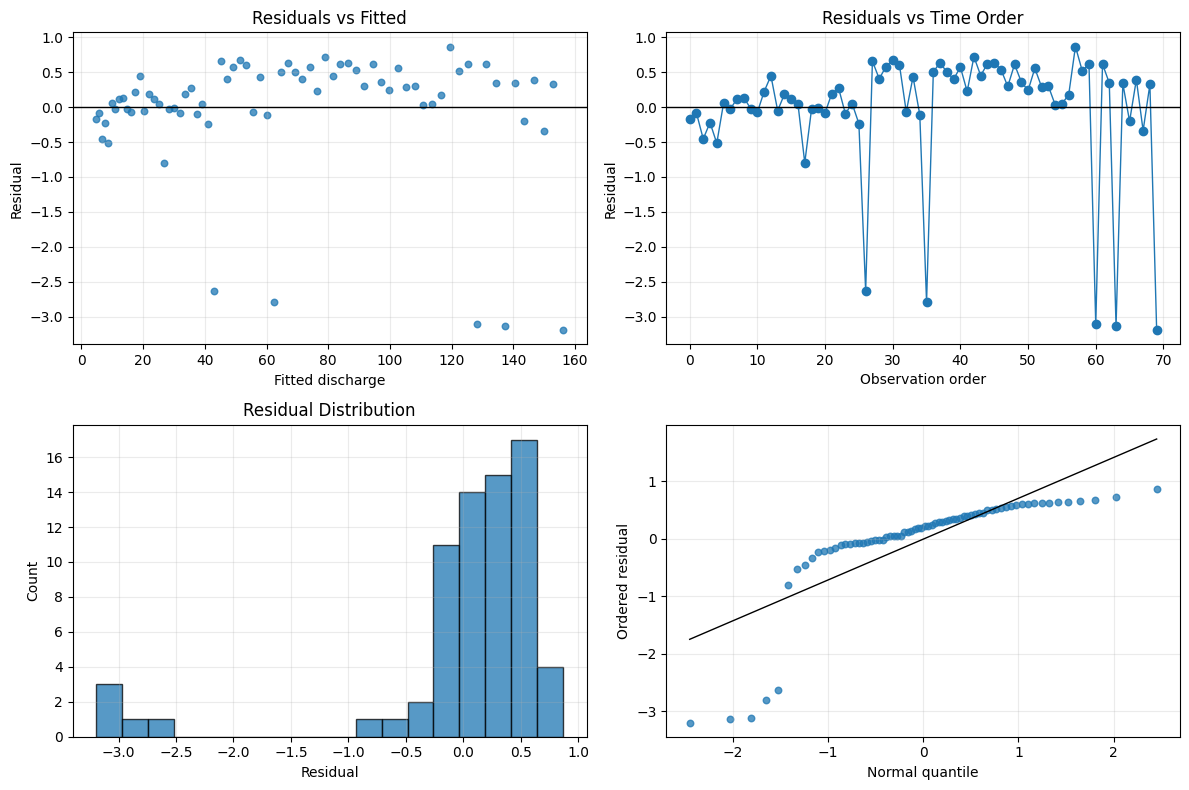

In [26]:
map_params = analysis.BayesianAnalysis.Results.MAP.Values
residuals = model.Residuals(map_params)

# Basic stats
mean_residual = np.mean(residuals)
std_residual = math.sqrt(sum(r*r for r in residuals) / len(residuals) - mean_residual*mean_residual)

print(f"Mean residual: {mean_residual:.4f} (should be near 0)")
print(f"Std deviation of residuals: {std_residual:.4f} (should be near σ = {map_params[-1]:.4f})")

# MAKE GRAPHS!!
# Residuals vs. fitted values: should show no trend
# Residuals vs. time: should show no autocorrelation (if temporal order known)
# Q-Q plot: should be approximately linear

residual_array = np.array([float(r) for r in residuals])
fitted_values = np.array([model.Predict(map_params, float(h)) for h in stage])
ordered_residuals = np.sort(residual_array)
plot_probs = (np.arange(1, len(ordered_residuals) + 1) - 0.5) / len(ordered_residuals)
normal_ref = Normal(0, 1)
theoretical = np.array([normal_ref.InverseCDF(float(p)) for p in plot_probs])

fig, axes = plt.subplots(2, 2, figsize=(12,8 ))
axes[0,0].scatter(fitted_values, residual_array, s=22, alpha=0.75)
axes[0,0].axhline(0, color="black", linewidth=1)
axes[0,0].set_xlabel("Fitted discharge")
axes[0,0].set_ylabel("Residual")
axes[0,0].set_title("Residuals vs Fitted")
axes[0,0].grid(alpha=0.25)

axes[0,1].plot(np.arange(len(residual_array)), residual_array, marker="o", linewidth=1)
axes[0,1].axhline(0, color="black", linewidth=1)
axes[0,1].set_xlabel("Observation order")
axes[0,1].set_ylabel("Residual")
axes[0,1].set_title("Residuals vs Time Order")
axes[0,1].grid(alpha=0.25)

axes[1,0].hist(residuals, bins=18, edgecolor="black", alpha=0.75)
axes[1,0].set_xlabel("Residual")
axes[1,0].set_ylabel("Count")
axes[1,0].set_title("Residual Distribution")
axes[1,0].grid(alpha=0.25)
plt.tight_layout()

axes[1,1].scatter(theoretical, ordered_residuals, s=22, alpha=0.75)
coef = np.polyfit(theoretical, ordered_residuals, 1)
axes[1,1].plot(theoretical, coef[0] * theoretical + coef[1], color="black", linewidth=1)
axes[1,1].set_xlabel("Normal quantile")
axes[1,1].set_ylabel("Ordered residual")
axes[1,1].grid(alpha=0.25)
plt.tight_layout()

### Synthetic Data Generation
For simulation studies or testing, generate synthetic data from a specified rating curve.

In [21]:
# Define true parameters
true_params = [
    0.5,                # ξ: zero-flow stage
    math.log10(10),     # log₁₀(α): coefficient
    2,                  # β: exponent           
    0.05                # σ: measurement error  
]

# Create model and set parameters
model = RatingCurve()
model.SetParameterValues(convert_to_dotnet_array(true_params))

# Generate synthetic data
synthetic_data = model.GenerateSyntheticData(
    sampleSize=200,
    minStage=1,
    maxStage=10,
    seed=1234
)

stage_ts = synthetic_data.Item1
discharge_ts = synthetic_data.Item2

print(f"Generated {len(stage_ts)} stage-discharge pairs")
print(
    "Stage range: {:.2f} to {:.2f}".format(
        min(s.Value for s in stage_ts),
        max(s.Value for s in stage_ts),
    )
)

print(
    "Discharge range: {:.1f} to {:.1f}".format(
        min(s.Value for s in discharge_ts),
        max(s.Value for s in discharge_ts),
    )
)

Generated 200 stage-discharge pairs
Stage range: 1.06 to 9.95
Discharge range: 2.5 to 1014.1


## Model Selection
### Choosing Numerics of Segments
The number of segments should be guided by physical knowledge of the channel:

| Situation | Recommended Segments |
|-----------|---------------------|
| Uniform channel geometry across observed range | 1 |
| Clear bankfull transition (channel to floodplain) | 2 |
| Multiple distinct controls (weir + channel + floodplain) | 3 |
| Uncertain | Start with 1, add segments if residuals show patterns |

### Comparing Models with Information Criteria

When physical reasoning is ambiguous, compare models using information criteria.
- **DIC (Deviance Information Criterion)**: Balances fit and complexity. Differences > 10 are considered strong evidence.
- **WAIC (Widely Applicable Information Criterion)**: More robust than DIC, especially for small samples.

1 segment(s): DIC = 188.3, WAIC = 192.3
2 segment(s): DIC = 188.5, WAIC = 192.5
3 segment(s): DIC = 188.8, WAIC = 192.7

Best model by DIC: 1 segment(s)


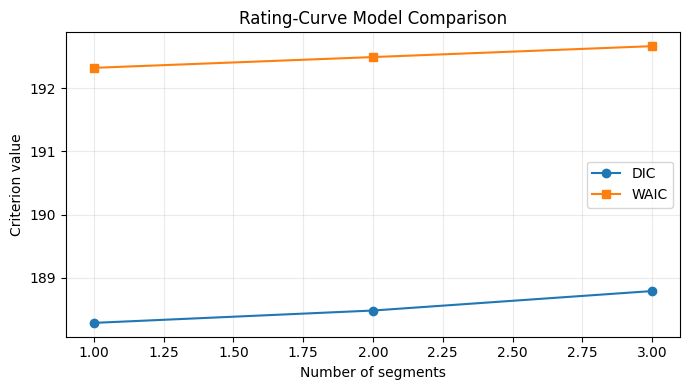

In [27]:
model_results = []

for n_segments in [1,2,3]:
    m = RatingCurve(stage_ts, discharge_ts, numberOfSegments=n_segments)
    a = RatingCurveAnalysis(m)
    a.BayesianAnalysis.Iterations = 15000
    a.BayesianAnalysis.WarmupIterations = 7500
    a.RunAsync().Wait()

    dic = a.BayesianAnalysis.DIC
    waic = a.BayesianAnalysis.WAIC
    
    model_results.append((n_segments, dic, waic))
    print(f"{n_segments} segment(s): DIC = {dic:.1f}, WAIC = {waic:.1f}")

# Lower values indicate better fit (penalized for complexity)
best = min(model_results, key=lambda r: r[1])       # r[1] is DIC
best_segments, best_dic, best_waic = best
print(f"\nBest model by DIC: {best_segments} segment(s)")

segment_counts = [1,2,3]
dic_values = [row[1] for row in model_results]
waic_values = [row[2] for row in model_results]
plt.figure(figsize=(7, 4))
plt.plot(segment_counts, dic_values, marker="o", label="DIC")
plt.plot(segment_counts, waic_values, marker="s", label="WAIC")
plt.xlabel("Number of segments")
plt.ylabel("Criterion value")
plt.title("Rating-Curve Model Comparison")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

## Examples
Pull full examples from BestFit docs if room -- there are 4 of them

In [ ]:
# rng = np.random.default_rng(5)
# stage = np.linspace(0.6, 5.0, 70)
# q_true = np.where(stage < 2.2, 18*(stage-0.3)**1.7, 65*(stage-0.3)**1.15)
# q_obs = np.maximum(0.1, q_true * (1 + rng.normal(0, 0.08, len(stage))))

# stage_ts = TimeSeries(TimeInterval.OneDay, DateTime(2000,1,1), convert_to_dotnet_array(stage))
# q_ts = TimeSeries(TimeInterval.OneDay, DateTime(2000,1,1), convert_to_dotnet_array(q_obs))

# curve = RatingCurve(stage_ts, q_ts, 2)
# curve.SetDefaultParameters()

# x0 = np.array([float(p.Value) for p in curve.Parameters], dtype=float)
# lower = np.array([float(p.LowerBound) for p in curve.Parameters], dtype=float)
# upper = np.array([float(p.UpperBound) for p in curve.Parameters], dtype=float)

# # A physically informed starting guess (clipped to model bounds)
# x_guess = np.array([np.log10(18), 1.7, 0.3, np.log10(65), 1.15, 2.2, 0.2], dtype=float)
# x_guess = np.clip(x_guess, lower + 1e-6, upper - 1e-6)

# def objective(x):
#     if np.any(x < lower) or np.any(x > upper):
#         return 1e12
#     try:
#         ll = float(curve.LogLikelihood(convert_to_dotnet_array(x)))
#         return -ll if np.isfinite(ll) else 1e12
#     except Exception:
#         return 1e12

# fit = minimize(objective, x_guess, method='Powell', bounds=list(zip(lower, upper)), options={'maxiter': 3000})
# p_hat = fit.x

# pred = np.array([float(curve.Predict(convert_to_dotnet_array(p_hat), float(h))) for h in stage])
# residuals = np.array(list(curve.Residuals(convert_to_dotnet_array(p_hat))), dtype=float)
# rmse = float(np.sqrt(np.mean(residuals**2)))

# print('Optimization success:', fit.success)
# print('Optimized parameter vector:', np.round(p_hat, 5))
# print('RMSE:', round(rmse, 3))

# fig, ax = plt.subplots(1, 2, figsize=(12,4))
# ax[0].scatter(stage, q_obs, s=20, alpha=0.65, label='Observed')
# ax[0].plot(stage, pred, color='crimson', lw=2, label='BestFit RatingCurve Predict')
# ax[0].set_title('Stage-Discharge Fit')
# ax[0].set_xlabel('Stage')
# ax[0].set_ylabel('Discharge')
# ax[0].grid(alpha=0.3)
# ax[0].legend()

# ax[1].axhline(0.0, color='black', lw=1)
# ax[1].scatter(stage, residuals, s=20)
# ax[1].set_title('Residuals from BestFit RatingCurve')
# ax[1].set_xlabel('Stage')
# ax[1].set_ylabel('Residual')
# ax[1].grid(alpha=0.3)

# plt.tight_layout()

<Figure size 640x480 with 0 Axes>

## Summary
In this notebook you        
$\checkmark$ Learned the mathematical foundation of rating curves and channel flow      
$\checkmark$ Estimated rating curve parameters      
$\checkmark$ Validated rating curve parameters      
$\checkmark$ Generated a rating table       
$\checkmark$ Generated synthetic data       

## Exercises
1. 